In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [3]:
df = pd.read_csv("c:/Users/Amir/Desktop/MLP/globalAirQuality.csv")
df

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2025-11-19 13:25:17.554219,CH,Zurich,47.377,8.542,27.899,74.179,41.474,6.677,50.869,1.028,103,7.079,52.443,7.452
17996,2025-11-19 14:25:17.554219,CH,Zurich,47.377,8.542,2.950,47.988,42.235,2.821,35.551,0.644,105,28.734,85.678,4.496
17997,2025-11-19 15:25:17.554219,CH,Zurich,47.377,8.542,61.347,72.908,46.976,5.763,66.492,0.947,122,21.951,72.311,9.660
17998,2025-11-19 16:25:17.554219,CH,Zurich,47.377,8.542,40.722,95.152,32.957,5.524,53.193,0.868,95,24.042,31.880,2.642


In [4]:
df.describe()

,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,23.065980,37.655560,40.369131,70.152228,32.055176,6.035508,48.065100,0.800595,104.645556,21.510251,57.714351,5.283910
std,26.156536,78.600701,17.647450,24.999440,13.820680,2.454790,14.950849,0.250254,25.616070,9.509444,18.844908,2.741712
min,-37.814000,-123.121000,0.025000,0.061000,0.013000,0.003000,0.114000,0.000000,16.000000,5.000000,25.002000,0.500000
25%,12.972000,2.352000,27.904500,53.125500,22.362500,4.360750,38.028500,0.633000,87.000000,13.357750,41.320000,2.937000
50%,29.232000,42.146000,40.286500,69.961000,32.019500,6.026000,48.142000,0.800500,103.000000,21.455500,57.847000,5.297000
75%,41.008000,103.820000,52.436250,87.256500,41.364250,7.715250,58.258500,0.969000,121.000000,29.688250,74.234750,7.662000
max,60.170000,174.763000,115.683000,161.810000,90.019000,16.559000,103.016000,1.832000,231.000000,37.998000,89.997000,9.999000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    18000 non-null  object 
 1   country      18000 non-null  object 
 2   city         18000 non-null  object 
 3   latitude     18000 non-null  float64
 4   longitude    18000 non-null  float64
 5   pm25         18000 non-null  float64
 6   pm10         18000 non-null  float64
 7   no2          18000 non-null  float64
 8   so2          18000 non-null  float64
 9   o3           18000 non-null  float64
 10  co           18000 non-null  float64
 11  aqi          18000 non-null  int64  
 12  temperature  18000 non-null  float64
 13  humidity     18000 non-null  float64
 14  wind_speed   18000 non-null  float64
dtypes: float64(11), int64(1), object(3)
memory usage: 2.1+ MB


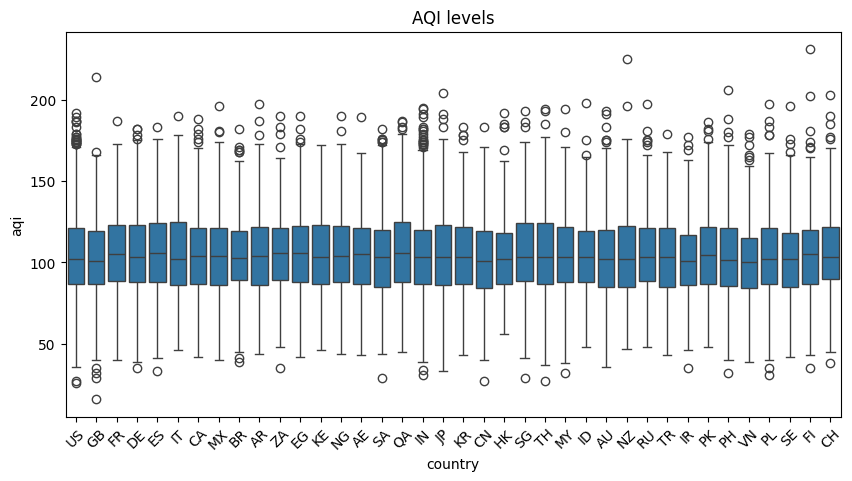

In [6]:
plt.figure(figsize=(10 , 5))
sns.boxplot(df , x="country" , y="aqi")
plt.title("AQI levels")
plt.xticks(rotation = 45)
plt.show()

In [9]:
numeric_cols = df.select_dtypes(include=[np.number])

skew_vlues = numeric_cols.apply(lambda x : skew(x.dropna()))

print(skew_vlues)


latitude      -0.957421
longitude     -0.483080
pm25           0.121962
pm10           0.024551
no2            0.104932
so2            0.064463
o3            -0.021979
co             0.014428
aqi            0.337432
temperature   -0.001738
humidity      -0.007769
wind_speed    -0.012331
dtype: float64


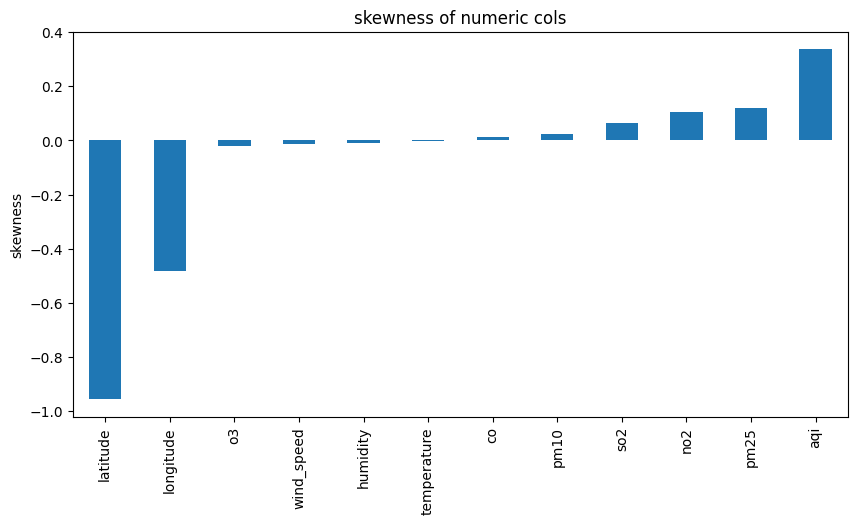

In [11]:
skew_vlues.sort_values().plot(kind = "bar" , figsize = (10 , 5))
plt.title("skewness of numeric cols")
plt.ylabel("skewness")
plt.show()


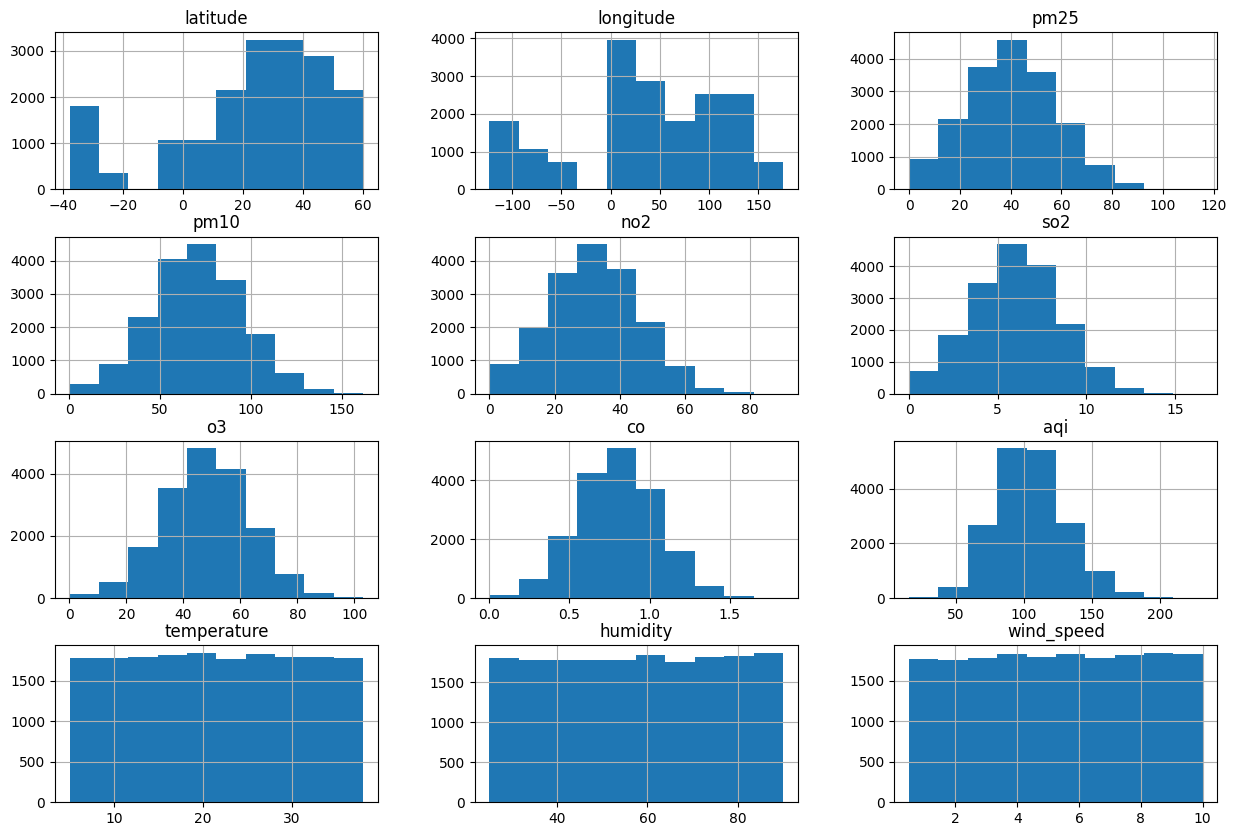

In [12]:
df.hist(figsize=(15 , 10))
plt.show()

In [17]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
Zurich_df = df[df["city"] == "Zurich"].copy().sort_values("timestamp").reset_index(drop= True)

print(f"samples: {len(Zurich_df)}")
print(f"data range : {Zurich_df["timestamp"].min()} to {Zurich_df["timestamp"].max()}")

print("\n temporal corr")

for lag in [1 , 3 , 6 , 12 , 24]:
    corr = Zurich_df["aqi"].autocorr(lag=lag)
    print(f"lag {lag:2d}h : {corr : .3f}")

samples: 360
data range : 2025-11-04 18:25:17.554219 to 2025-11-19 17:25:17.554219

 temporal corr
lag  1h :  0.004
lag  3h : -0.088
lag  6h : -0.048
lag 12h : -0.035
lag 24h :  0.002


C:\Users\Amir\AppData\Local\Temp\ipykernel_21556\235625237.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


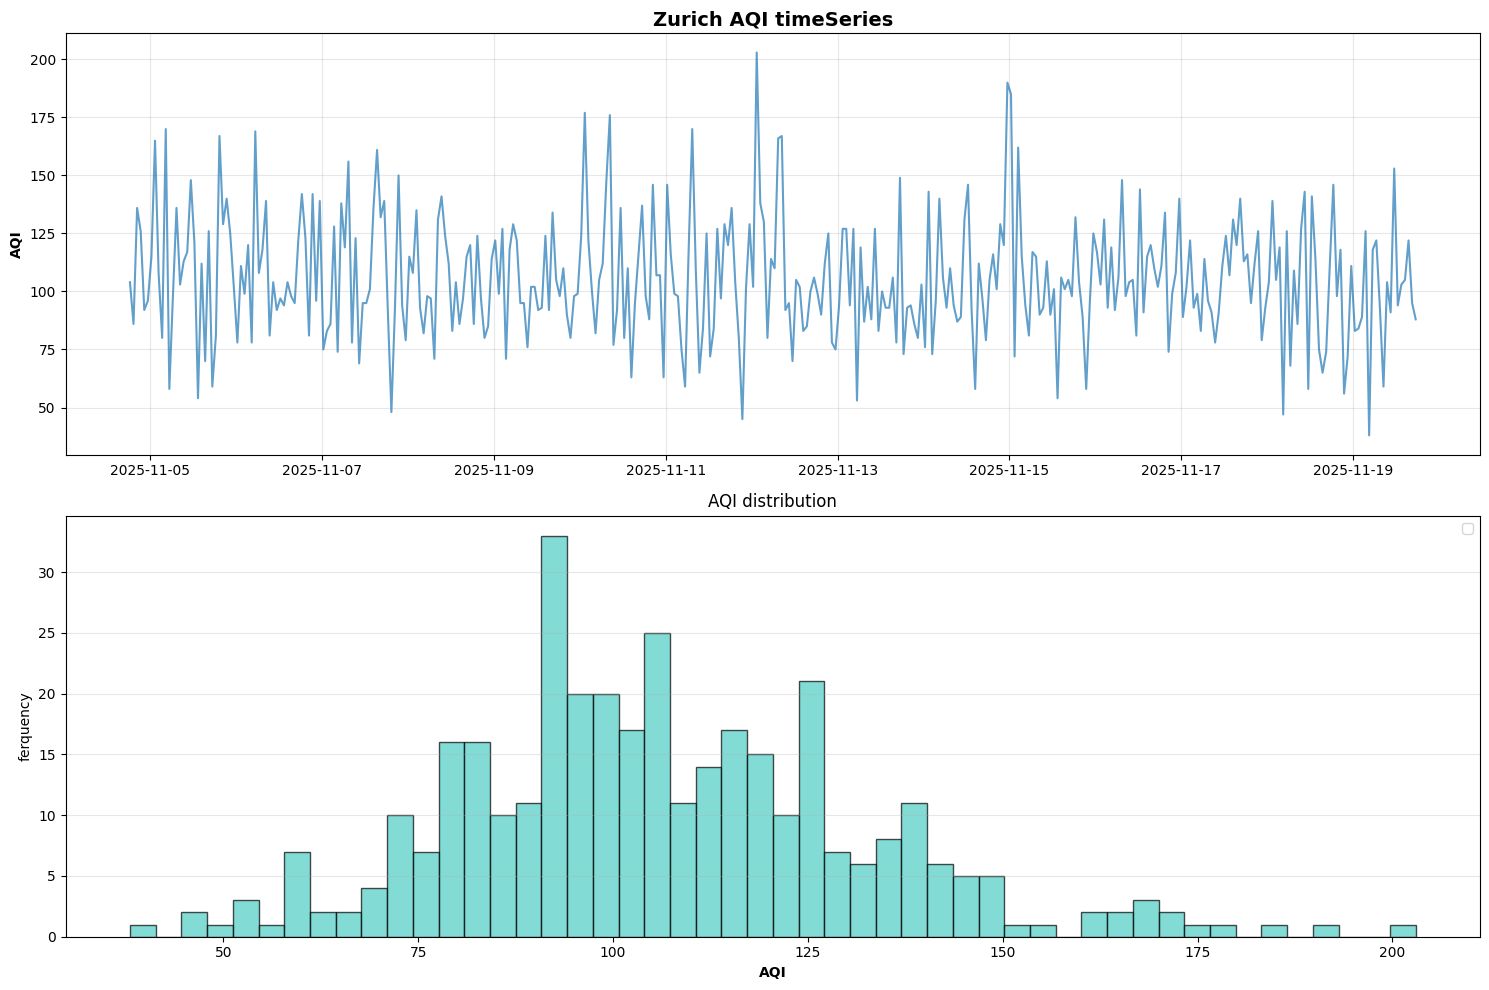

In [25]:
fig , axes = plt.subplots(2 , 1 , figsize = (15 , 10))


axes[0].plot(Zurich_df["timestamp"] , Zurich_df["aqi"] , linewidth = 1.5 , alpha = 0.7)
axes[0].set_title("Zurich AQI timeSeries" , fontsize = 14 , fontweight = "bold")
axes[0].set_ylabel("AQI" , fontweight = "bold")
axes[0].grid(True , alpha = 0.3)

axes[1].hist(Zurich_df["aqi"] , bins= 50 , color = "#4ECDC4" , alpha = 0.7  , edgecolor = "black")
axes[1].set_title("AQI distribution")
axes[1].set_xlabel("AQI" , fontweight = "bold")
axes[1].set_ylabel("ferquency")
axes[1].legend()
axes[1].grid(True , alpha = 0.3 , axis = "y")



plt.tight_layout()
plt.show()


In [28]:
print(f"Mean : {Zurich_df["aqi"].mean()}")
print(f"std : {Zurich_df["aqi"].std()}")
print(f"range : [{Zurich_df["aqi"].min():.1f} , {Zurich_df["aqi"].max():.1f}]")

Mean : 105.72222222222223
std : 26.15510954849272
range : [38.0 , 203.0]
